<a href="https://colab.research.google.com/github/shahdelmasry12/University-Machine-Learning-Project/blob/main/Diabetes_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **About Dataset**


*   This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases.
*  The objective of the dataset is to diagnostically predict whether or not a patient has diabetes.
*   The datasets consists of several medical predictor variables and one target variable.
                                              
*   Predictor variables includes the number of pregnancies the patient has had, their BMI, insulin level, age	,BloodPressure	,SkinThickness,Glucose	,	DiabetesPedigreeFunction	,Outcome                                              

# **Imports**

In [1]:
#Imports
import numpy as np
import pandas as pd#DataFrame,processing cleaning
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns #Visulization
from sklearn.metrics import roc_curve, roc_auc_score

#Machine Learning
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score,classification_report
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# **Load data**

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/shahdelmasry12/University-Machine-Learning-Project/refs/heads/main/diabetes_dataset.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# **Explore and Clean data**

In [3]:
df.shape

(768, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
##Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [6]:
#Check Missing vallues
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [7]:
#summery statistical about data
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Handling Invalid Zero Values
   * Columns(	BloodPressure	,SkinThickness	Insulin	,BMI)  whose  Minimum values ​​equal 0


In [8]:
#Replace Zero to nan
cols_with_zero = ['Glucose', 'BloodPressure', 'BMI', 'Insulin', 'SkinThickness']
for col in cols_with_zero:
    df[col] = df[col].replace(0, np.nan)

In [9]:
#Check Missing vallues
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [10]:
#Fillna by medien
df=df.fillna(df.median())

In [11]:
#summery statistical about data
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [12]:
#Check Missing vallues
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


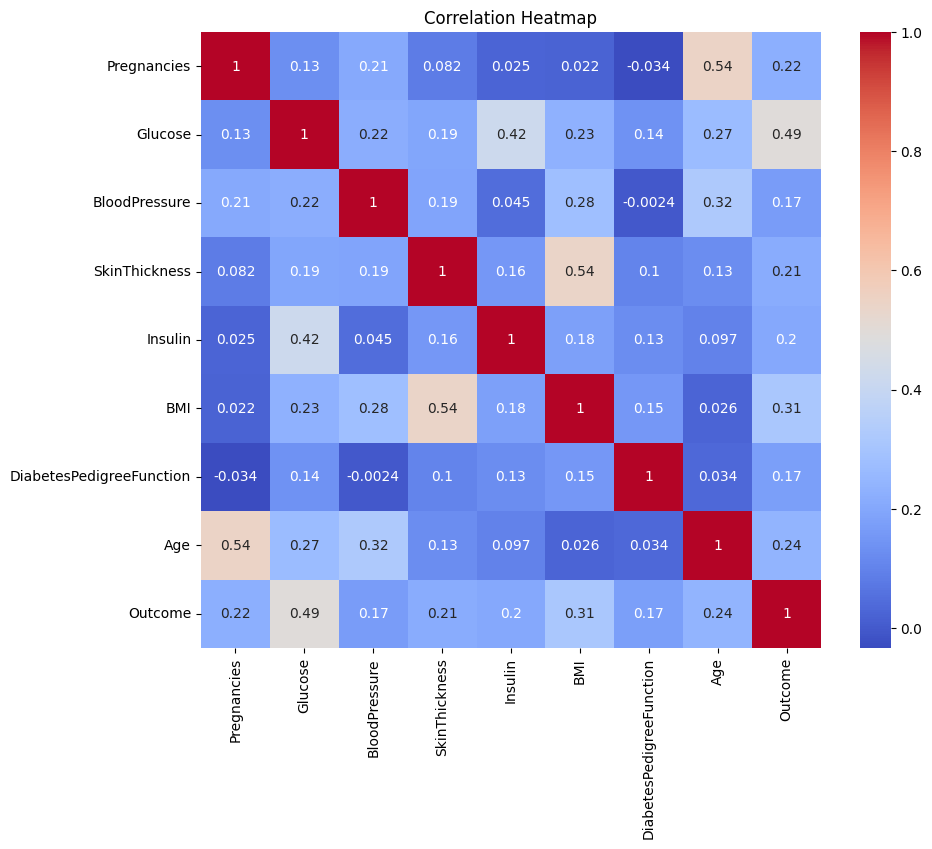

In [13]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


# **Feature Engineering**

In [14]:
def add_all_features(df):
    df = df.copy()

    # 1. BMI × Age — الضغط التراكمي
    df['BMI_Age_Interaction'] = df['BMI'] * df['Age']

    # 2. نسبة السكر للإنسولين — مقاومة الإنسولين
    df['Glucose_Insulin_Ratio'] = df['Glucose'] / (df['Insulin'] + 1)

    # 3. تصنيف BMI الطبي
    def bmi_category(x):
        if x < 18.5: return 0   # Underweight
        elif x < 25: return 1   # Normal
        elif x < 30: return 2   # Overweight
        else:        return 3   # Obese
    df['BMI_Category'] = df['BMI'].apply(bmi_category)

    # 4. علامة الخطر العمري
    df['High_Risk_Age'] = (df['Age'] > 45).astype(int)

    # 5. تصنيف السكر حسب معايير WHO
    def glucose_level(g):
        if g < 100:  return 0   # Normal
        elif g < 126: return 1  # Pre-diabetes
        else:         return 2  # Diabetes range
    df['Glucose_Level'] = df['Glucose'].apply(glucose_level)

    # 6. درجة الخطر المركّبة
    df['Composite_Risk'] = (
        df['Glucose'] / 200 +
        df['BMI']     / 50  +
        df['Age']     / 100
    )

    return df

In [15]:
df=add_all_features(df)

In [16]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Age_Interaction,Glucose_Insulin_Ratio,BMI_Category,High_Risk_Age,Glucose_Level,Composite_Risk
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,1680.0,1.174603,3,1,2,1.912
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,824.6,0.674603,2,0,0,1.267
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,745.6,1.452381,1,0,2,1.701
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,590.1,0.936842,2,0,0,1.217
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,1422.3,0.810651,3,0,2,1.877


In [17]:
#summery statistical about data
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Age_Interaction,Glucose_Insulin_Ratio,BMI_Category,High_Risk_Age,Glucose_Level,Composite_Risk
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958,1080.906771,1.054449,2.485677,0.153646,1.136719,1.589794
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951,437.813986,0.684436,0.739853,0.360844,0.786659,0.275594
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000,382.200000,0.206323,0.000000,0.000000,0.000000,0.972000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000,744.800000,0.746032,2.000000,0.000000,0.750000,1.387750
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000,987.250000,0.936508,3.000000,0.000000,1.000000,1.570000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000,1357.200000,1.175893,3.000000,0.000000,2.000000,1.788250
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000,2697.000000,12.000000,3.000000,1.000000,2.000000,2.375000


# **Vsulization(EDA)**

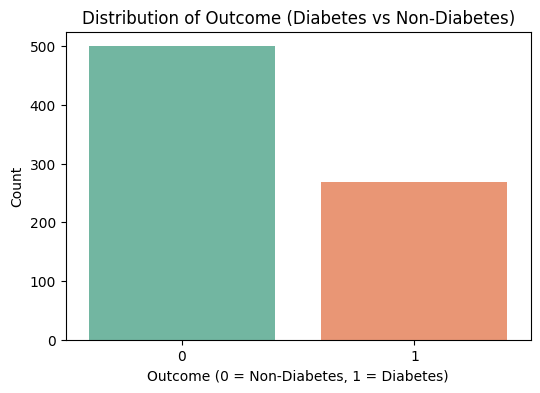

In [18]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Outcome', hue='Outcome', palette='Set2', legend=False)
plt.title('Distribution of Outcome (Diabetes vs Non-Diabetes)')
plt.xlabel('Outcome (0 = Non-Diabetes, 1 = Diabetes)')
plt.ylabel('Count')
plt.show()

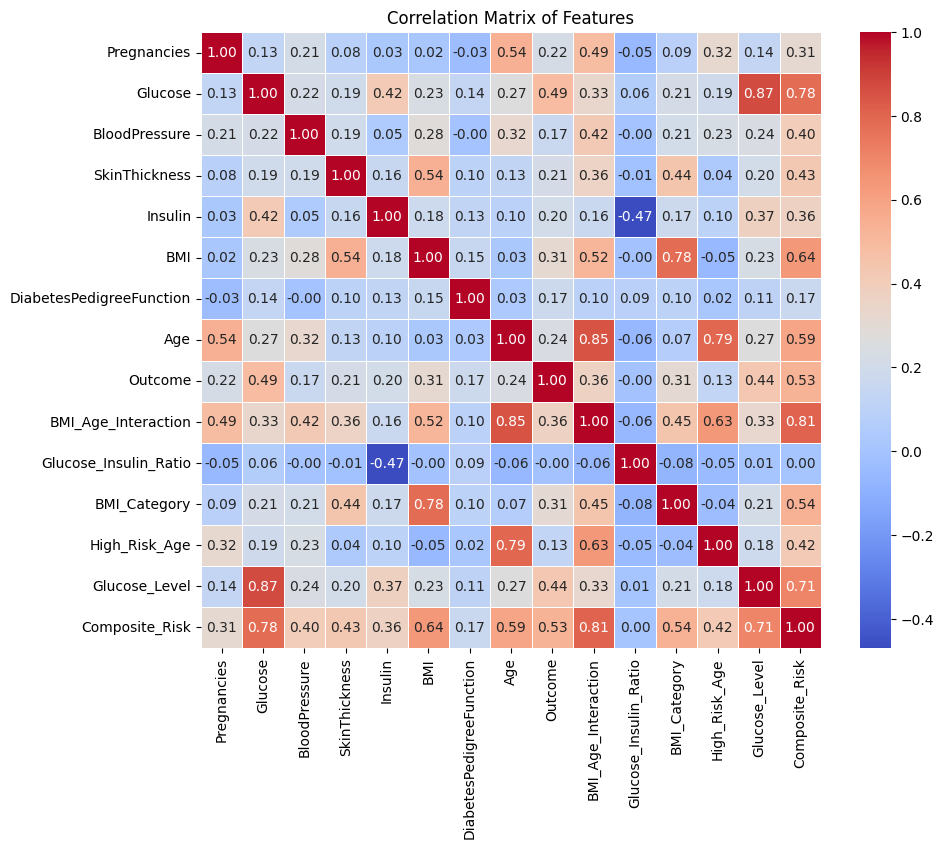

In [19]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.show()

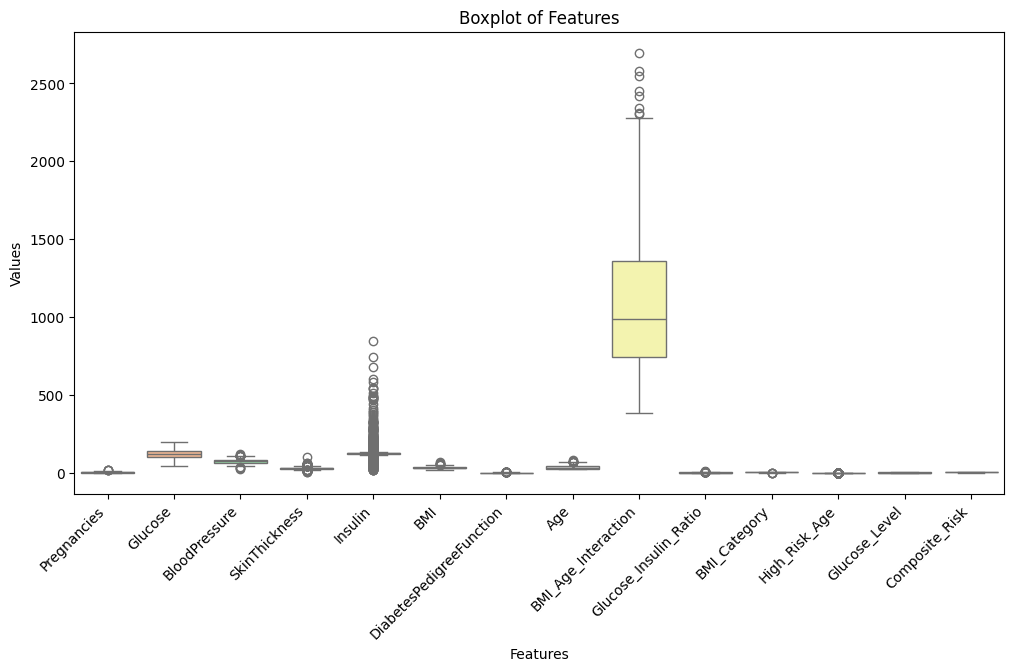

In [20]:
# Detect Outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.drop(columns=['Outcome']), palette='pastel')
plt.xticks(rotation=45, ha='right')
plt.title('Boxplot of Features')
plt.xlabel('Features')
plt.ylabel('Values')
plt.show()

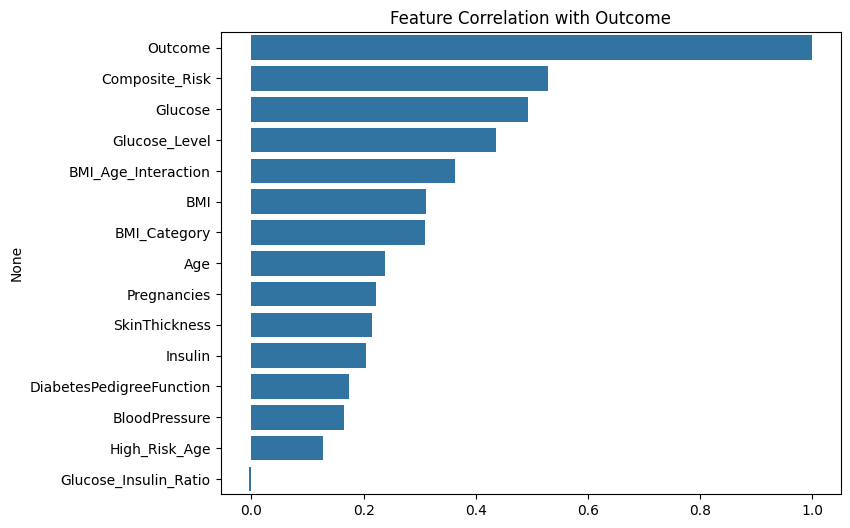

In [21]:
# Feature Correlation with Outcome
corr = df.corr()["Outcome"].sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=corr.values, y=corr.index)
plt.title("Feature Correlation with Outcome")
plt.show()

# **Preprocessing**

In [22]:
# Drop duplicate rows if any
before = df.shape[0]
df = df.drop_duplicates()
print(f'Rows before: {before} | Rows after: {df.shape[0]} | Dropped: {before - df.shape[0]}')

Rows before: 768 | Rows after: 768 | Dropped: 0


# 2. Outlier Detection & Capping (IQR Method)

In [23]:
numerical_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                  'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

df_before_clip = df[numerical_cols].describe().loc[['min','max']]

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

print('Outlier capping applied. New min/max:')
df[numerical_cols].describe().loc[['min','max']]

# I handled outliers using IQR and applied clipping instead of removing data to preserve information

Outlier capping applied. New min/max:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
min,0.0,44.0,40.0,14.5,112.875,18.20,0.078,21.0
max,13.5,199.0,104.0,42.5,135.875,50.25,1.200,66.5


# 3. Feature Scaling (StandardScaler)

In [24]:
from sklearn.preprocessing import StandardScaler

scale_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
              'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age',
              'BMI_Age_Interaction', 'Glucose_Insulin_Ratio', 'Composite_Risk']

scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

print('Scaling complete. Sample statistics after scaling:')
df[scale_cols].describe().loc[['mean','std']].round(4)

Scaling complete. Sample statistics after scaling:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,BMI_Age_Interaction,Glucose_Insulin_Ratio,Composite_Risk
mean,-0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000
std,1.0007,1.0007,1.0007,1.0007,1.0007,1.0007,1.0007,1.0007,1.0007,1.0007,1.0007


 ## 4. Handle Class Imbalance (SMOTE)


In [25]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Before SMOTE:')
print(y_train.value_counts())

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('\nAfter SMOTE:')
print(y_train_res.value_counts())
print(f'\nTrain size: {X_train_res.shape[0]} | Test size: {X_test.shape[0]}')

Before SMOTE:
Outcome
0    400
1    214
Name: count, dtype: int64

After SMOTE:
Outcome
0    400
1    400
Name: count, dtype: int64

Train size: 800 | Test size: 154


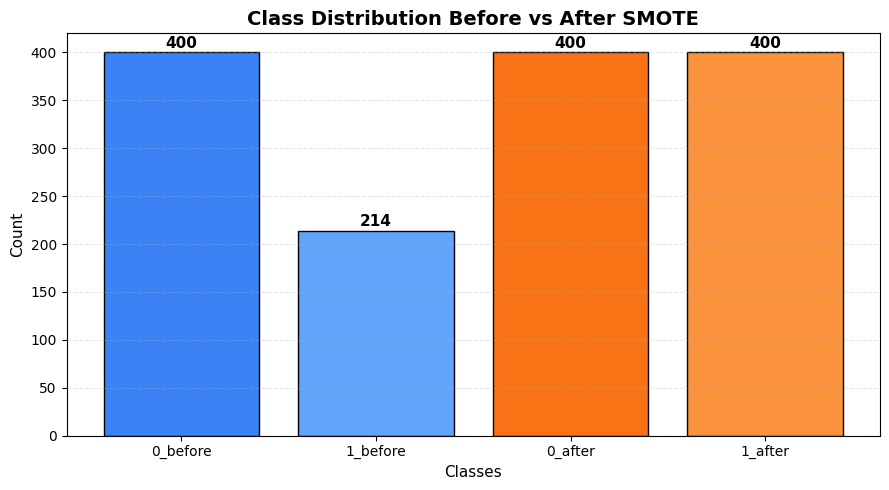

In [26]:
import matplotlib.pyplot as plt

before = y_train.value_counts().sort_index()
after  = y_train_res.value_counts().sort_index()

labels = ['0_before','1_before','0_after','1_after']
values = [before[0], before[1], after[0], after[1]]

colors = ['#3B82F6', '#60A5FA', '#F97316', '#FB923C']

plt.figure(figsize=(9,5))
bars = plt.bar(labels, values, color=colors, edgecolor='black')

# أرقام فوق الأعمدة
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5,
             str(int(height)), ha='center', fontsize=11, fontweight='bold')

plt.title("Class Distribution Before vs After SMOTE", fontsize=14, fontweight='bold')
plt.xlabel("Classes", fontsize=11)
plt.ylabel("Count", fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

##  Pre-Processing Summary
| Step | Action |
|------|--------|
| Zero → NaN | Replaced biologically impossible zeros with NaN |
| Imputation | Filled NaN with column median |
| Outlier capping | IQR 1.5× fence applied to 8 numerical columns |
| Feature scaling | StandardScaler on 11 numerical/engineered columns |
| Class imbalance | SMOTE applied to training set only |
| Train/Test split | 80/20 stratified split |

# Modeling and Evaluation


### Logistic Regression


In [27]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_res, y_train_res)

LogisticRegression(max_iter=1000)

In [28]:
y_pred_log = log_model.predict(X_test)


In [29]:
print("Logistic Regression Results")
print("-"*30)
print("Accuracy:", accuracy_score(y_test, y_pred_log))


Logistic Regression Results
------------------------------
Accuracy: 0.7337662337662337


In [30]:
print("Logistic Regression Results")
print("-"*30)
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))


Logistic Regression Results
------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.73      0.78       100
           1       0.60      0.74      0.66        54

    accuracy                           0.73       154
   macro avg       0.72      0.74      0.72       154
weighted avg       0.75      0.73      0.74       154



In [31]:
print("Logistic Regression Results")
print("-"*30)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

Logistic Regression Results
------------------------------

Confusion Matrix:
 [[73 27]
 [14 40]]


### Decision Tree


In [32]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_res, y_train_res)



DecisionTreeClassifier(random_state=42)

In [33]:
y_pred_dt = dt_model.predict(X_test)


In [34]:
print("Decision Tree Results")
print("-"*30)
print("Accuracy:", accuracy_score(y_test, y_pred_dt))


Decision Tree Results
------------------------------
Accuracy: 0.7142857142857143


In [35]:
print("Decision Tree Results")
print("-"*30)
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))


Decision Tree Results
------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.74      0.77       100
           1       0.58      0.67      0.62        54

    accuracy                           0.71       154
   macro avg       0.69      0.70      0.70       154
weighted avg       0.73      0.71      0.72       154



In [36]:
print("Decision Tree Results")
print("-"*30)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

Decision Tree Results
------------------------------

Confusion Matrix:
 [[74 26]
 [18 36]]


### SVM


In [37]:

svm_model = SVC(kernel='rbf')
svm_model.fit(X_train_res, y_train_res)


SVC()

In [38]:
y_pred_svm = svm_model.predict(X_test)


In [39]:
print("SVM Results")
print("-"*30)
print("Accuracy:", accuracy_score(y_test, y_pred_svm))


SVM Results
------------------------------
Accuracy: 0.7662337662337663


In [40]:
print("SVM Results")
print("-"*30)
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))


SVM Results
------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.78      0.81       100
           1       0.65      0.74      0.69        54

    accuracy                           0.77       154
   macro avg       0.75      0.76      0.75       154
weighted avg       0.78      0.77      0.77       154



In [41]:
print("SVM Results")
print("-"*30)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

SVM Results
------------------------------

Confusion Matrix:
 [[78 22]
 [14 40]]


### Cross Validation  (Logistic Regression)

In [42]:

cv_log = cross_val_score(log_model, X_train_res, y_train_res, cv=5)
print("Logistic Regression CV Accuracy:", cv_log.mean())

Logistic Regression CV Accuracy: 0.76


### Cross Validation  (Decision Tree)

In [43]:
cv_dt = cross_val_score(dt_model, X_train_res, y_train_res, cv=5)
print("Decision Tree CV Accuracy:", cv_dt.mean())

Decision Tree CV Accuracy: 0.7375


### Cross Validation  (SVM )

In [44]:
cv_svm = cross_val_score(svm_model, X_train_res, y_train_res, cv=5)
print("SVM CV Accuracy:", cv_svm.mean())

SVM CV Accuracy: 0.7725000000000001


# Model comparison

In [45]:

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "SVM"],
    "Test Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_svm)
    ],
    "CV Mean Accuracy": [
        cv_log.mean(),
        cv_dt.mean(),
        cv_svm.mean()
    ]
})


comparison = comparison.sort_values(by="Test Accuracy", ascending=False)

comparison

,Model,Test Accuracy,CV Mean Accuracy
2,SVM,0.766234,0.7725
0,Logistic Regression,0.733766,0.7600
1,Decision Tree,0.714286,0.7375


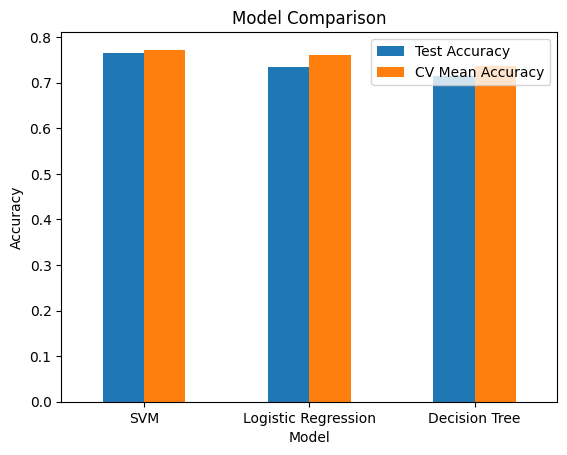

In [46]:

comparison.set_index("Model")[["Test Accuracy", "CV Mean Accuracy"]].plot(kind="bar")
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.show()

### Conclusion

- Logistic Regression performed well due to the linear nature of the dataset.
- Decision Tree may overfit but gives interpretability.
- SVM provides strong performance but requires tuning.

- Based on Cross Validation, the best model is: **[Logistic Regression]**

- Future improvements:
  - Hyperparameter tuning
  - Feature scaling optimization
  - Trying ensemble models like Random Forest